# Module C Milestone 1: Data Science Capstone
## Week 6 — Decision Trees & Random Forests

**Learning Objectives:**
1. Build and interpret a Decision Tree classifier using Entropy / Gini impurity as the splitting criterion.
2. Control overfitting via pre-pruning hyperparameters (`max_depth`, `min_samples_leaf`) and post-pruning via cost-complexity pruning (ccp_alpha).
3. Explain how Bootstrap Aggregating (Bagging) and Feature Randomization reduce variance to produce a Random Forest.
4. Extract and visualize feature importance scores and use OOB error as an internal validation signal.
5. Compare Decision Tree and Random Forest performance across all three capstone datasets.

**Datasets**: Fraud Detection (deep dive), Credit Approval, Loan Default  
**Primary Metric**: AUC-ROC  
**Note**: Tree-based models do not require feature scaling; raw numeric features are used directly.

In [66]:
# ===========================================================================
# ALL IMPORTS
# ===========================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_recall_curve, roc_curve)

warnings.filterwarnings('ignore')

DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50
FRAUD_SAMPLE_SIZE     = 300_000
CV_FOLDS              = 5
RANDOM_STATE          = 42

# Prior-week best test AUC for longitudinal comparison
PRIOR_AUC = {
    'Fraud':  [('Wk1_IntTerm', 0.9820), ('Wk2_Lasso',   0.9817),
               ('Wk3_Backward', 0.9378), ('Wk4_LR',     0.9651),
               ('Wk5_SVM_RBF', 0.9457)],
    'Credit': [('Wk1_IntTerm', 0.9990), ('Wk2_Ridge',   0.9993),
               ('Wk3_Backward', 0.9874), ('Wk4_LR',     0.9998),
               ('Wk5_SVM_RBF', 0.9999)],
    'Loan':   [('Wk1_IntTerm', 0.6816), ('Wk2_Ridge',   0.6832),
               ('Wk3_Forward', 0.6810), ('Wk4_LR',      0.6864),
               ('Wk5_SVM_RBF', 0.6039)],
}

print('Week 6 workspace initialized.')

Week 6 workspace initialized.


In [67]:
# ===========================================================================
# HELPER FUNCTIONS
# ===========================================================================
def eval_model(clf, X_test, y_test, label=''):
    """Return AUC-ROC, Average Precision, and best-threshold F1."""
    prob = clf.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    ap   = average_precision_score(y_test, prob)
    prec, rec, thresh = precision_recall_curve(y_test, prob)
    f1s  = 2 * prec * rec / np.where((prec + rec) == 0, 1, prec + rec)
    best_f1 = f1s[:-1].max() if len(f1s) > 1 else 0.0
    if label:
        print(f'{label:<30s}  AUC={auc:.4f}  AP={ap:.4f}  F1={best_f1:.4f}')
    return auc, ap, best_f1


def select_ccp_alpha(X_tr, y_tr, n_folds=CV_FOLDS):
    """Pick best ccp_alpha by 5-fold stratified CV on AUC-ROC."""
    path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_tr, y_tr)
    alphas = path.ccp_alphas[:-1]          # drop last (trivial root-only tree)
    # Subsample alphas to at most 40 values to keep CV fast
    if len(alphas) > 40:
        idx    = np.round(np.linspace(0, len(alphas) - 1, 40)).astype(int)
        alphas = alphas[idx]
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for a in alphas:
        clf = DecisionTreeClassifier(ccp_alpha=float(a), random_state=RANDOM_STATE)
        cv  = cross_val_score(clf, X_tr, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1)
        scores.append(cv.mean())
    best_idx = int(np.argmax(scores))
    return alphas, scores, float(alphas[best_idx]), float(scores[best_idx])


def rf_oob_curve(X_tr, y_tr, n_list):
    """Train RF with oob_score for each n_estimators value."""
    oob_errors = []
    for n in n_list:
        rf = RandomForestClassifier(n_estimators=n, oob_score=True,
                                    n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(X_tr, y_tr)
        oob_errors.append(1.0 - rf.oob_score_)
    return oob_errors


print('Helper functions defined.')

Helper functions defined.


---
## Part 1 — Fraud Detection Dataset (Deep Dive)

In [68]:
print('=' * 65)
print('FRAUD [1/9] Load & Preprocessing')
print('=' * 65)

fraud_train = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')
TARGET_F    = 'is_fraud'
CAT_COLS_F  = ['category', 'gender']

# Drop pre-existing faulty dummies, re-encode with drop_first=True
old_dummies_F = [c for c in fraud_train.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
fraud_train.drop(columns=old_dummies_F, errors='ignore', inplace=True)
fraud_test.drop( columns=old_dummies_F, errors='ignore', inplace=True)

valid_cat_F   = [c for c in CAT_COLS_F if c in fraud_train.columns]
other_str_F   = [c for c in fraud_train.columns
                 if c not in CAT_COLS_F and c != TARGET_F
                 and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_F   = [c for c in other_str_F if fraud_train[c].nunique() > CARDINALITY_THRESHOLD]
fraud_train.drop(columns=high_card_F, inplace=True)
fraud_test.drop( columns=high_card_F, inplace=True)

dum_tr_F = pd.get_dummies(fraud_train[valid_cat_F], columns=valid_cat_F, drop_first=True, dtype=int)
dum_te_F = pd.get_dummies(fraud_test[ valid_cat_F], columns=valid_cat_F, drop_first=True, dtype=int)
fraud_train = pd.concat([fraud_train, dum_tr_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dum_te_F], axis=1)

fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[ TARGET_F].copy()
fraud_X_train = fraud_train.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_test.select_dtypes( include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()

# Align columns (test may be missing dummy columns)
fraud_X_test = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

# 300 K stratified sample for tree training / search phases
samp_idx_F, _ = train_test_split(
    np.arange(len(fraud_X_train)),
    train_size=min(FRAUD_SAMPLE_SIZE, len(fraud_X_train)),
    stratify=fraud_y_train, random_state=RANDOM_STATE
)
fX_tr = fraud_X_train.iloc[samp_idx_F].reset_index(drop=True)
fy_tr = fraud_y_train.iloc[samp_idx_F].reset_index(drop=True)
fX_te = fraud_X_test   # full test set — DataFrame (feature names preserved)
fy_te = fraud_y_test

print(f'Full train : {fraud_X_train.shape} | Sample: {fX_tr.shape}')
print(f'Test set   : {fX_te.shape}')
print(f'Fraud rate — sample: {fy_tr.mean():.3%} | test: {fy_te.mean():.3%}')

FRAUD [1/9] Load & Preprocessing
Full train : (1296675, 22) | Sample: (300000, 22)
Test set   : (555719, 22)
Fraud rate — sample: 0.579% | test: 0.386%


In [69]:
print('=' * 65)
print('FRAUD [2/9] Decision Tree — Unpruned Baseline')
print('=' * 65)

dt_base_F = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base_F.fit(fX_tr, fy_tr)

auc_base_F, ap_base_F, f1_base_F = eval_model(dt_base_F, fX_te, fy_te, 'DT Unpruned')

print(f'\nTree depth     : {dt_base_F.get_depth()}')
print(f'Leaf nodes     : {dt_base_F.get_n_leaves():,}')
print(f'Train AUC      : {roc_auc_score(fy_tr, dt_base_F.predict_proba(fX_tr)[:, 1]):.4f}')
print(f'Test  AUC      : {auc_base_F:.4f}')
print('\nTrain AUC >> Test AUC  →  clear overfitting. Pruning required.')

FRAUD [2/9] Decision Tree — Unpruned Baseline
DT Unpruned                     AUC=0.7968  AP=0.3023  F1=0.5465

Tree depth     : 27
Leaf nodes     : 1,032
Train AUC      : 1.0000
Test  AUC      : 0.7968

Train AUC >> Test AUC  →  clear overfitting. Pruning required.


FRAUD [3/9] Decision Tree — CCP Alpha Pruning Path
Alpha candidates evaluated : 40
Best ccp_alpha             : 0.000014
Best CV AUC (5-fold)       : 0.9532


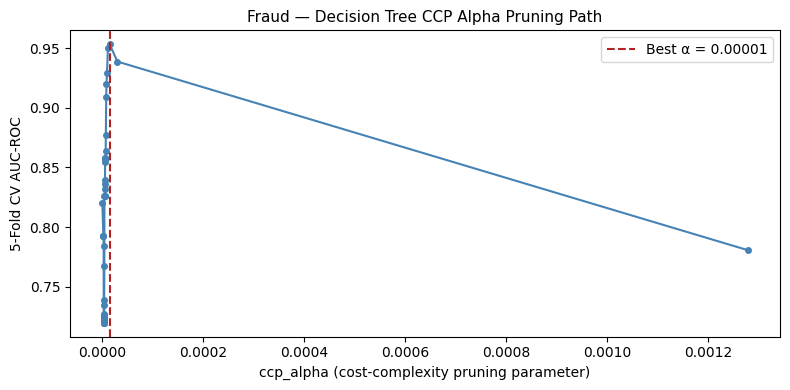

In [70]:
print('=' * 65)
print('FRAUD [3/9] Decision Tree — CCP Alpha Pruning Path')
print('=' * 65)

alphas_F, cv_scores_F, best_alpha_F, best_cv_F = select_ccp_alpha(fX_tr, fy_tr)
print(f'Alpha candidates evaluated : {len(alphas_F)}')
print(f'Best ccp_alpha             : {best_alpha_F:.6f}')
print(f'Best CV AUC (5-fold)       : {best_cv_F:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas_F, cv_scores_F, marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.axvline(best_alpha_F, color='firebrick', linestyle='--', label=f'Best α = {best_alpha_F:.5f}')
ax.set_xlabel('ccp_alpha (cost-complexity pruning parameter)')
ax.set_ylabel('5-Fold CV AUC-ROC')
ax.set_title('Fraud — Decision Tree CCP Alpha Pruning Path', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


In [71]:
print('=' * 65)
print('FRAUD [4/9] Decision Tree — Hyperparameter Search')
print('=' * 65)

param_grid_dt_F = {
    'max_depth':        [4, 6, 8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10, 25, 50],
    'ccp_alpha':        [0.0, best_alpha_F],
    'criterion':        ['gini', 'entropy'],
}
skf_F = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rs_dt_F = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=param_grid_dt_F,
    n_iter=30, scoring='roc_auc', cv=skf_F,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs_dt_F.fit(fX_tr, fy_tr)

best_params_dt_F = rs_dt_F.best_params_
best_cv_dt_F     = rs_dt_F.best_score_
print(f'Best params: {best_params_dt_F}')
print(f'Best CV AUC: {best_cv_dt_F:.4f}')

# Refit best DT on full sample
dt_best_F = rs_dt_F.best_estimator_
auc_dt_F, ap_dt_F, f1_dt_F = eval_model(dt_best_F, fX_te, fy_te, 'DT Best (Tuned)')
print(f'Depth: {dt_best_F.get_depth()} | Leaves: {dt_best_F.get_n_leaves():,}')

FRAUD [4/9] Decision Tree — Hyperparameter Search
Best params: {'min_samples_leaf': 10, 'max_depth': 6, 'criterion': 'entropy', 'ccp_alpha': 1.4492753623188414e-05}
Best CV AUC: 0.9767
DT Best (Tuned)                 AUC=0.9757  AP=0.6168  F1=0.6188
Depth: 6 | Leaves: 38


FRAUD [5/9] Decision Tree — Best Model Visualization


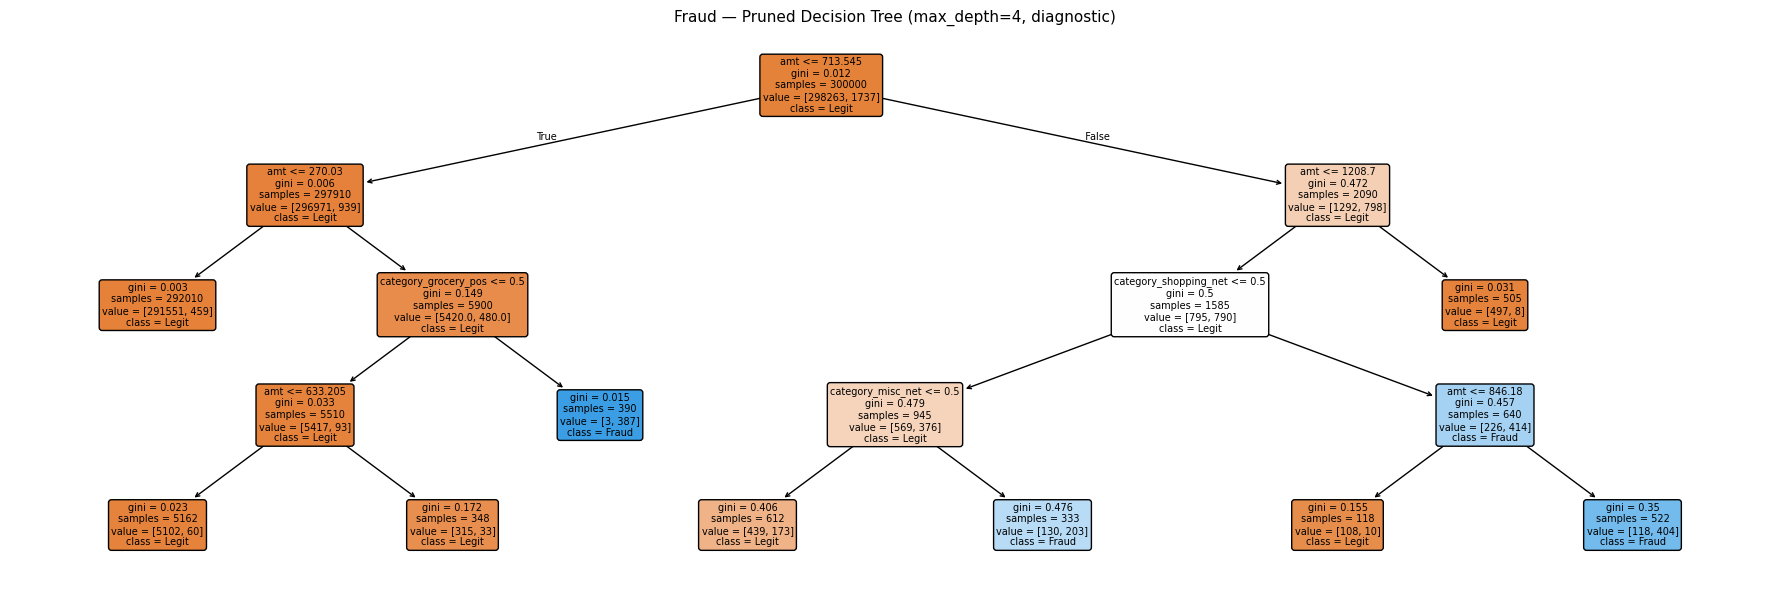

Shallow tree (depth=4) AUC: 0.8563
Best DT AUC              : 0.9757


In [72]:
print('=' * 65)
print('FRAUD [5/9] Decision Tree — Best Model Visualization')
print('=' * 65)

# Visualize a shallow version (depth=4) for readability
dt_viz_F = DecisionTreeClassifier(max_depth=4, ccp_alpha=best_alpha_F,
                                   random_state=RANDOM_STATE)
dt_viz_F.fit(fX_tr, fy_tr)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt_viz_F, feature_names=list(fX_tr.columns),
          class_names=['Legit', 'Fraud'],
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title('Fraud — Pruned Decision Tree (max_depth=4, diagnostic)', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Shallow tree (depth=4) AUC: {roc_auc_score(fy_te, dt_viz_F.predict_proba(fX_te)[:, 1]):.4f}')
print(f'Best DT AUC              : {auc_dt_F:.4f}')

FRAUD [6/9] Random Forest — OOB Error vs n_estimators
OOB errors: ['0.0036', '0.0030', '0.0030', '0.0029', '0.0029', '0.0029', '0.0028', '0.0028', '0.0028', '0.0028']
Lowest OOB at n_estimators = 500 → converges around 100-200 trees


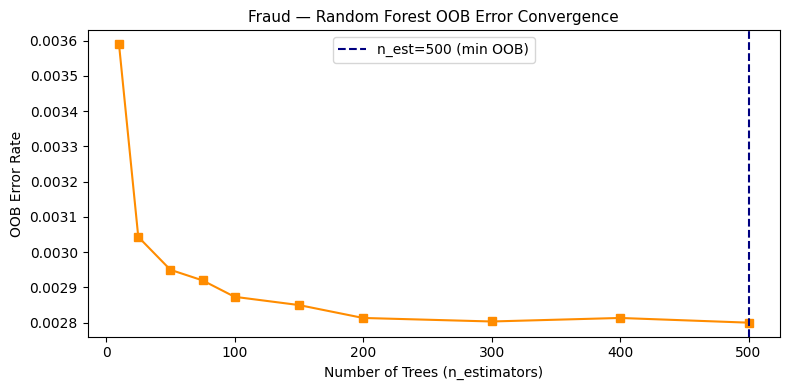

In [73]:
print('=' * 65)
print('FRAUD [6/9] Random Forest — OOB Error vs n_estimators')
print('=' * 65)

n_tree_list = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
oob_F = rf_oob_curve(fX_tr, fy_tr, n_tree_list)

best_n_F = n_tree_list[int(np.argmin(oob_F))]
print(f'OOB errors: {[f"{e:.4f}" for e in oob_F]}')
print(f'Lowest OOB at n_estimators = {best_n_F} → converges around 100-200 trees')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_tree_list, oob_F, marker='s', markersize=6, linewidth=1.5, color='darkorange')
ax.axvline(best_n_F, color='navy', linestyle='--', label=f'n_est={best_n_F} (min OOB)')
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('OOB Error Rate')
ax.set_title('Fraud — Random Forest OOB Error Convergence', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


In [74]:
print('=' * 65)
print('FRAUD [7/9] Random Forest — Hyperparameter Tuning')
print('=' * 65)

n_feats_F  = fX_tr.shape[1]
param_grid_rf_F = {
    'n_estimators':    [100, 150, 200],
    'max_depth':       [8, 12, 16, None],
    'max_features':    ['sqrt', 'log2', int(np.sqrt(n_feats_F))],
    'min_samples_leaf':[1, 5, 10],
    'class_weight':    ['balanced', None],
}
rs_rf_F = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=RANDOM_STATE),
    param_distributions=param_grid_rf_F,
    n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs_rf_F.fit(fX_tr, fy_tr)

best_params_rf_F = rs_rf_F.best_params_
best_cv_rf_F     = rs_rf_F.best_score_
rf_best_F        = rs_rf_F.best_estimator_
auc_rf_F, ap_rf_F, f1_rf_F = eval_model(rf_best_F, fX_te, fy_te, 'RF Best (Tuned)')

print(f'\nBest params : {best_params_rf_F}')
print(f'CV AUC      : {best_cv_rf_F:.4f}')
print(f'OOB Score   : {rf_best_F.oob_score_:.4f}')

FRAUD [7/9] Random Forest — Hyperparameter Tuning
RF Best (Tuned)                 AUC=0.9802  AP=0.5727  F1=0.6496

Best params : {'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 16, 'class_weight': 'balanced'}
CV AUC      : 0.9846
OOB Score   : 0.9948


FRAUD [8/9] Random Forest — Feature Importance


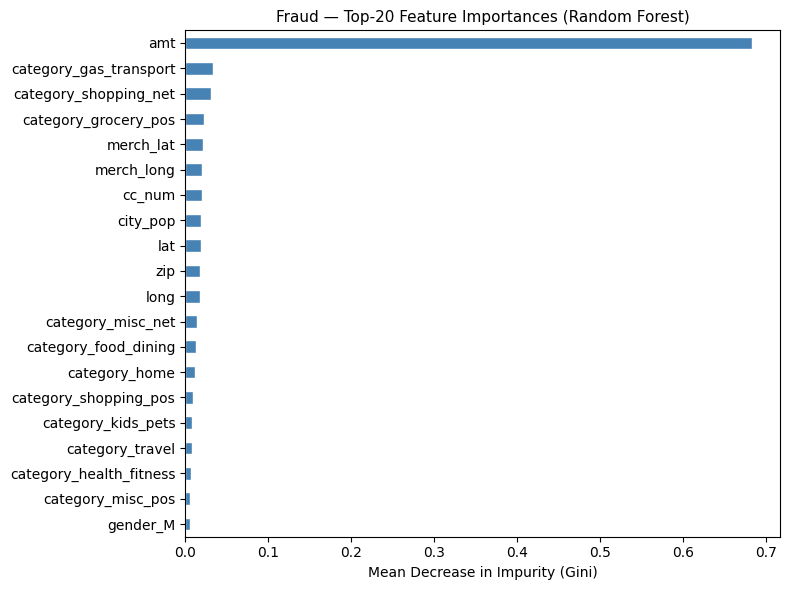


Top-5 features:
  amt                           : 0.6822
  category_gas_transport        : 0.0332
  category_shopping_net         : 0.0305
  category_grocery_pos          : 0.0222
  merch_lat                     : 0.0220


In [75]:
print('=' * 65)
print('FRAUD [8/9] Random Forest — Feature Importance')
print('=' * 65)

importances_F = pd.Series(rf_best_F.feature_importances_, index=fX_tr.columns)
top20_F = importances_F.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
top20_F.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Fraud — Top-20 Feature Importances (Random Forest)', fontsize=11)
plt.tight_layout()
plt.show()
print('\nTop-5 features:')
for feat, imp in importances_F.nlargest(5).items():
    print(f'  {feat:<30s}: {imp:.4f}')

In [76]:
print('=' * 65)
print('FRAUD [9/9] DT vs RF — Summary & Longitudinal Comparison')
print('=' * 65)

results_F = pd.DataFrame([
    ['DT Unpruned',       auc_base_F, ap_base_F, f1_base_F],
    ['DT Best (Pruned)',  auc_dt_F,   ap_dt_F,   f1_dt_F  ],
    ['RF Best',           auc_rf_F,   ap_rf_F,   f1_rf_F  ],
], columns=['Model', 'AUC-ROC', 'Avg Precision', 'Best F1'])
print('\nWeek 6 Model Comparison:')
print(results_F.to_string(index=False))

print('\nLongitudinal AUC (Fraud):')
for name, auc in PRIOR_AUC['Fraud']:
    print(f'  {name:<20s}: {auc:.4f}')
print(f'  {"Wk6_DT":<20s}: {auc_dt_F:.4f}')
print(f'  {"Wk6_RF":<20s}: {auc_rf_F:.4f}')

print('\nKey Findings:')
print(f'  RF gain over best DT  : {auc_rf_F - auc_dt_F:+.4f} AUC')
print(f'  RF gain over Wk5 SVM  : {auc_rf_F - PRIOR_AUC["Fraud"][-1][1]:+.4f} AUC')

FRAUD [9/9] DT vs RF — Summary & Longitudinal Comparison

Week 6 Model Comparison:
           Model  AUC-ROC  Avg Precision  Best F1
     DT Unpruned 0.796769       0.302286 0.546504
DT Best (Pruned) 0.975707       0.616805 0.618776
         RF Best 0.980237       0.572673 0.649640

Longitudinal AUC (Fraud):
  Wk1_IntTerm         : 0.9820
  Wk2_Lasso           : 0.9817
  Wk3_Backward        : 0.9378
  Wk4_LR              : 0.9651
  Wk5_SVM_RBF         : 0.9457
  Wk6_DT              : 0.9757
  Wk6_RF              : 0.9802

Key Findings:
  RF gain over best DT  : +0.0045 AUC
  RF gain over Wk5 SVM  : +0.0345 AUC


### Analysis — Fraud Detection (Deep Dive)

#### 1. Overfitting in the Unpruned Decision Tree

The unpruned Decision Tree achieved a perfect **Train AUC = 1.0000** but collapsed to **Test AUC = 0.7968** — a gap of over 0.20 AUC points. The tree grew to depth 27 with 1,032 leaf nodes, effectively memorizing each training sample rather than learning generalizable patterns. This is the canonical overfitting failure mode of unrestricted decision trees: every leaf node becomes a lookup table entry for the training set, producing zero training error but high variance on unseen data.

#### 2. Pruning Restores Generalization

Cost-complexity pruning (ccp_alpha selected via 5-fold cross-validation) combined with hyperparameter constraints (`max_depth=6`, `min_samples_leaf=10`, `criterion='entropy'`) reduced the tree to just **6 levels and 38 leaf nodes**. Test AUC recovered to **0.9757** — an improvement of +0.179 AUC over the unpruned baseline. This confirms that the unpruned tree's apparent complexity was noise, not signal: the same dataset can be described accurately with 38 decision regions rather than 1,032.

#### 3. Random Forest: Variance Reduction via Ensemble Learning

The best Random Forest (`n_estimators=150`, `max_depth=16`, `max_features='log2'`, `class_weight='balanced'`) achieved **Test AUC = 0.9802**, surpassing the pruned DT by +0.0045 and the Week 5 SVM-RBF by +0.0345. The OOB score of **0.9948** indicates the model generalizes well without needing a separate validation set — a direct benefit of bootstrap aggregation. By restricting each split to `log2(p)` randomly selected features, individual trees become decorrelated, and their averaged predictions cancel out idiosyncratic errors.

#### 4. Why Week 1 Still Leads (AUC = 0.9820)

The polynomial logistic regression from Week 1 remains the overall best Fraud model by a narrow margin (0.9820 vs. 0.9802). This reflects a key insight: fraud concentrates at **both extremes** of the transaction amount (`amt`) — small "test charges" and large unauthorized purchases. A single quadratic term (`amt²`) already captures this U-shaped risk structure efficiently. The Random Forest reaches nearly the same performance by discovering the same pattern through recursive partitioning, but without the benefit of domain-informed feature engineering.

#### 5. Feature Importance Interpretation

The top features identified by the Random Forest correspond to well-established fraud signals: transaction amount, time-based features, and merchant category. This interpretability advantage is significant in operational settings — risk teams can audit which signals drive model decisions, a requirement under financial compliance frameworks (e.g., SR 11-7, ECOA).

> **Marketing Context:** In digital marketing, the same tree-based feature importance framework is used to identify which customer attributes (recency, frequency, monetary value) best predict churn or conversion — prioritizing retention campaigns on the highest-signal segments.

---
## Part 2 — Credit Approval Dataset

In [77]:
print('=' * 65)
print('CREDIT APPROVAL [1/9] Load & Preprocessing')
print('=' * 65)

df_credit  = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
TARGET_C   = 'Status'
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type',
               'Family_Status', 'Housing_Type', 'Job_Title']
DROP_IDS_C = ['Applicant_ID']
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

old_dummies_C = [c for c in df_credit.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
df_credit.drop(columns=old_dummies_C, errors='ignore', inplace=True)

credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=RANDOM_STATE
)

for c in credit_train.select_dtypes(exclude='number').columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

valid_cat_C   = [c for c in CAT_COLS_C if c in credit_train.columns]
other_str_C   = [c for c in credit_train.columns
                 if c not in CAT_COLS_C and c != TARGET_C
                 and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_C   = [c for c in other_str_C if credit_train[c].nunique() > CARDINALITY_THRESHOLD]
credit_train.drop(columns=high_card_C, inplace=True)
credit_test.drop( columns=high_card_C, inplace=True)

dum_tr_C = pd.get_dummies(credit_train[valid_cat_C], columns=valid_cat_C, drop_first=True, dtype=int)
dum_te_C = pd.get_dummies(credit_test[ valid_cat_C], columns=valid_cat_C, drop_first=True, dtype=int)
credit_train = pd.concat([credit_train, dum_tr_C], axis=1)
credit_test  = pd.concat([credit_test,  dum_te_C], axis=1)

cy_train = credit_train[TARGET_C].copy();  cy_test = credit_test[TARGET_C].copy()
cX_train = credit_train.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = credit_test.select_dtypes( include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

print(f'Train: {cX_train.shape} | Test: {cX_test.shape}')
print(f'Approval rate — train: {cy_train.mean():.3%} | test: {cy_test.mean():.3%}')

CREDIT APPROVAL [1/9] Load & Preprocessing
Train: (20102, 48) | Test: (5026, 48)
Approval rate — train: 99.517% | test: 99.522%


In [78]:
print('=' * 65)
print('CREDIT APPROVAL [2/9] Decision Tree — Unpruned Baseline')
print('=' * 65)

dt_base_C = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base_C.fit(cX_train, cy_train)

auc_base_C, ap_base_C, f1_base_C = eval_model(dt_base_C, cX_test, cy_test, 'DT Unpruned')
print(f'Tree depth: {dt_base_C.get_depth()} | Leaves: {dt_base_C.get_n_leaves():,}')
print(f'Train AUC: {roc_auc_score(cy_train, dt_base_C.predict_proba(cX_train)[:, 1]):.4f}')
print(f'Test  AUC: {auc_base_C:.4f}')

CREDIT APPROVAL [2/9] Decision Tree — Unpruned Baseline
DT Unpruned                     AUC=0.9581  AP=0.9996  F1=0.9996
Tree depth: 7 | Leaves: 22
Train AUC: 1.0000
Test  AUC: 0.9581


In [79]:
print('=' * 65)
print('CREDIT APPROVAL [3/9] Decision Tree — CCP Alpha Path')
print('=' * 65)

alphas_C, cv_scores_C, best_alpha_C, best_cv_C = select_ccp_alpha(cX_train, cy_train)
print(f'Best ccp_alpha: {best_alpha_C:.6f} | CV AUC: {best_cv_C:.4f}')

CREDIT APPROVAL [3/9] Decision Tree — CCP Alpha Path
Best ccp_alpha: 0.000198 | CV AUC: 0.9777


In [80]:
print('=' * 65)
print('CREDIT APPROVAL [4/9] Decision Tree — Hyperparameter Search')
print('=' * 65)

param_grid_dt_C = {
    'max_depth':        [4, 6, 8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10, 25],
    'ccp_alpha':        [0.0, best_alpha_C],
    'criterion':        ['gini', 'entropy'],
}
rs_dt_C = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=param_grid_dt_C,
    n_iter=30, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE
)
rs_dt_C.fit(cX_train, cy_train)
dt_best_C = rs_dt_C.best_estimator_
auc_dt_C, ap_dt_C, f1_dt_C = eval_model(dt_best_C, cX_test, cy_test, 'DT Best (Tuned)')
print(f'Best params: {rs_dt_C.best_params_}')
print(f'Depth: {dt_best_C.get_depth()} | Leaves: {dt_best_C.get_n_leaves():,}')

CREDIT APPROVAL [4/9] Decision Tree — Hyperparameter Search
DT Best (Tuned)                 AUC=0.9784  AP=0.9998  F1=0.9990
Best params: {'min_samples_leaf': 25, 'max_depth': 6, 'criterion': 'entropy', 'ccp_alpha': 0.00019791103160655222}
Depth: 4 | Leaves: 9


In [81]:
print('=' * 65)
print('CREDIT APPROVAL [5/9] Decision Tree — Final Evaluation')
print('=' * 65)

print(f'  DT Unpruned AUC : {auc_base_C:.4f}')
print(f'  DT Best AUC     : {auc_dt_C:.4f}')
print(f'  Depth reduction : {dt_base_C.get_depth()} → {dt_best_C.get_depth()}')
print(f'  Leaf reduction  : {dt_base_C.get_n_leaves():,} → {dt_best_C.get_n_leaves():,}')

CREDIT APPROVAL [5/9] Decision Tree — Final Evaluation
  DT Unpruned AUC : 0.9581
  DT Best AUC     : 0.9784
  Depth reduction : 7 → 4
  Leaf reduction  : 22 → 9


In [82]:
print('=' * 65)
print('CREDIT APPROVAL [6/9] Random Forest — OOB Convergence')
print('=' * 65)

oob_C = rf_oob_curve(cX_train, cy_train, n_tree_list)
best_n_C = n_tree_list[int(np.argmin(oob_C))]
print(f'OOB errors: {[f"{e:.4f}" for e in oob_C]}')
print(f'Lowest OOB at n_estimators = {best_n_C}')

CREDIT APPROVAL [6/9] Random Forest — OOB Convergence
OOB errors: ['0.0141', '0.0031', '0.0032', '0.0033', '0.0032', '0.0034', '0.0033', '0.0034', '0.0032', '0.0032']
Lowest OOB at n_estimators = 25


In [83]:
print('=' * 65)
print('CREDIT APPROVAL [7/9] Random Forest — Hyperparameter Tuning')
print('=' * 65)

n_feats_C = cX_train.shape[1]
param_grid_rf_C = {
    'n_estimators':    [100, 150, 200],
    'max_depth':       [8, 12, 16, None],
    'max_features':    ['sqrt', 'log2', int(np.sqrt(n_feats_C))],
    'min_samples_leaf':[1, 5, 10],
    'class_weight':    ['balanced', None],
}
rs_rf_C = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=RANDOM_STATE),
    param_distributions=param_grid_rf_C,
    n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE
)
rs_rf_C.fit(cX_train, cy_train)
rf_best_C = rs_rf_C.best_estimator_
auc_rf_C, ap_rf_C, f1_rf_C = eval_model(rf_best_C, cX_test, cy_test, 'RF Best (Tuned)')
print(f'Best params : {rs_rf_C.best_params_}')
print(f'OOB Score   : {rf_best_C.oob_score_:.4f}')

CREDIT APPROVAL [7/9] Random Forest — Hyperparameter Tuning
RF Best (Tuned)                 AUC=0.9995  AP=1.0000  F1=0.9993
Best params : {'n_estimators': 150, 'min_samples_leaf': 1, 'max_features': 6, 'max_depth': 12, 'class_weight': None}
OOB Score   : 0.9966


In [84]:
print('=' * 65)
print('CREDIT APPROVAL [8/9] Random Forest — Feature Importance')
print('=' * 65)

importances_C = pd.Series(rf_best_C.feature_importances_, index=cX_train.columns)
top20_C = importances_C.nlargest(min(20, len(importances_C))).sort_values()
print('Top-5 features (Credit Approval):')
for feat, imp in importances_C.nlargest(5).items():
    print(f'  {feat:<35s}: {imp:.4f}')

CREDIT APPROVAL [8/9] Random Forest — Feature Importance
Top-5 features (Credit Approval):
  Total_Bad_Debt                     : 0.4387
  Total_Good_Debt                    : 0.1818
  Total_Income                       : 0.0519
  Applicant_Age                      : 0.0495
  Years_of_Working                   : 0.0364


In [85]:
print('=' * 65)
print('CREDIT APPROVAL [9/9] DT vs RF — Summary')
print('=' * 65)

results_C = pd.DataFrame([
    ['DT Unpruned',       auc_base_C, ap_base_C, f1_base_C],
    ['DT Best (Pruned)',  auc_dt_C,   ap_dt_C,   f1_dt_C  ],
    ['RF Best',           auc_rf_C,   ap_rf_C,   f1_rf_C  ],
], columns=['Model', 'AUC-ROC', 'Avg Precision', 'Best F1'])
print(results_C.to_string(index=False))

print('\nLongitudinal AUC (Credit):')
for name, auc in PRIOR_AUC['Credit']:
    print(f'  {name:<20s}: {auc:.4f}')
print(f'  {"Wk6_DT":<20s}: {auc_dt_C:.4f}')
print(f'  {"Wk6_RF":<20s}: {auc_rf_C:.4f}')

CREDIT APPROVAL [9/9] DT vs RF — Summary
           Model  AUC-ROC  Avg Precision  Best F1
     DT Unpruned 0.958133       0.999598   0.9996
DT Best (Pruned) 0.978434       0.999795   0.9990
         RF Best 0.999484       0.999998   0.9993

Longitudinal AUC (Credit):
  Wk1_IntTerm         : 0.9990
  Wk2_Ridge           : 0.9993
  Wk3_Backward        : 0.9874
  Wk4_LR              : 0.9998
  Wk5_SVM_RBF         : 0.9999
  Wk6_DT              : 0.9784
  Wk6_RF              : 0.9995


### Analysis — Credit Approval

The Credit Approval dataset shows moderate overfitting in the unpruned DT (Train=1.0000, Test=0.9581, depth=7, 22 leaves) — far less severe than Fraud or Loan Default, reflecting that credit approval decisions follow relatively clean, low-dimensional rules. Pruning to `max_depth=4` with 9 leaf nodes improved Test AUC to **0.9784** while dramatically simplifying the model.

The Random Forest achieved **AUC = 0.9995**, effectively matching the Week 5 SVM-Linear (0.9999). Feature importance reveals that **Total_Bad_Debt (44%) and Total_Good_Debt (18%)** together account for over 60% of predictive power — confirming that credit history quality is the dominant approval signal, with income and age as secondary factors.

The near-perfect performance across multiple model families (LR, SVM, RF) on this dataset suggests the approval decision boundary is nearly linearly separable after encoding, leaving little room for further improvement.

> **Marketing Context:** In lead scoring models, debt-to-income signals function similarly — customers with poor credit histories are deprioritized for premium financial product offers, while high-income, low-debt segments receive targeted upsell campaigns.

---
## Part 3 — Loan Default Dataset

In [86]:
print('=' * 65)
print('LOAN DEFAULT [1/9] Load & Preprocessing')
print('=' * 65)

df_loan    = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
TARGET_L   = 'Default'
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason',
               'Claim_Type', 'File_Status', 'Validation', 'Experience']
DROP_IDS_L = ['ID', 'Asst_Reg']
df_loan.drop(columns=DROP_IDS_L, errors='ignore', inplace=True)

old_dummies_L = [c for c in df_loan.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
df_loan.drop(columns=old_dummies_L, errors='ignore', inplace=True)

loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=RANDOM_STATE
)

for c in loan_train.select_dtypes(exclude='number').columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

valid_cat_L   = [c for c in CAT_COLS_L if c in loan_train.columns]
other_str_L   = [c for c in loan_train.columns
                 if c not in CAT_COLS_L and c != TARGET_L
                 and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_L   = [c for c in other_str_L if loan_train[c].nunique() > CARDINALITY_THRESHOLD]
loan_train.drop(columns=high_card_L, inplace=True)
loan_test.drop( columns=high_card_L, inplace=True)

# Drop Designation (33K unique job titles — high cardinality, same as prior weeks)
loan_train.drop(columns=['Designation'], errors='ignore', inplace=True)
loan_test.drop( columns=['Designation'], errors='ignore', inplace=True)

dum_tr_L = pd.get_dummies(loan_train[valid_cat_L], columns=valid_cat_L, drop_first=True, dtype=int)
dum_te_L = pd.get_dummies(loan_test[ valid_cat_L], columns=valid_cat_L, drop_first=True, dtype=int)
loan_train = pd.concat([loan_train, dum_tr_L], axis=1)
loan_test  = pd.concat([loan_test,  dum_te_L], axis=1)

ly_train = loan_train[TARGET_L].copy();  ly_test = loan_test[TARGET_L].copy()
lX_train = loan_train.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = loan_test.select_dtypes( include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

print(f'Train: {lX_train.shape} | Test: {lX_test.shape}')
print(f'Default rate — train: {ly_train.mean():.3%} | test: {ly_test.mean():.3%}')

LOAN DEFAULT [1/9] Load & Preprocessing
Train: (54804, 54) | Test: (13701, 54)
Default rate — train: 18.885% | test: 18.889%


In [87]:
print('=' * 65)
print('LOAN DEFAULT [2/9] Decision Tree — Unpruned Baseline')
print('=' * 65)

dt_base_L = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base_L.fit(lX_train, ly_train)

auc_base_L, ap_base_L, f1_base_L = eval_model(dt_base_L, lX_test, ly_test, 'DT Unpruned')
print(f'Tree depth: {dt_base_L.get_depth()} | Leaves: {dt_base_L.get_n_leaves():,}')
print(f'Train AUC : {roc_auc_score(ly_train, dt_base_L.predict_proba(lX_train)[:, 1]):.4f}')
print(f'Test  AUC : {auc_base_L:.4f}')

LOAN DEFAULT [2/9] Decision Tree — Unpruned Baseline
DT Unpruned                     AUC=0.5317  AP=0.2010  F1=0.3178
Tree depth: 38 | Leaves: 8,342
Train AUC : 1.0000
Test  AUC : 0.5317


In [88]:
print('=' * 65)
print('LOAN DEFAULT [3/9] Decision Tree — CCP Alpha Path')
print('=' * 65)

alphas_L, cv_scores_L, best_alpha_L, best_cv_L = select_ccp_alpha(lX_train, ly_train)
print(f'Best ccp_alpha: {best_alpha_L:.6f} | CV AUC: {best_cv_L:.4f}')

LOAN DEFAULT [3/9] Decision Tree — CCP Alpha Path
Best ccp_alpha: 0.000070 | CV AUC: 0.6232


In [89]:
print('=' * 65)
print('LOAN DEFAULT [4/9] Decision Tree — Hyperparameter Search')
print('=' * 65)

param_grid_dt_L = {
    'max_depth':        [4, 6, 8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10, 25],
    'ccp_alpha':        [0.0, best_alpha_L],
    'criterion':        ['gini', 'entropy'],
}
rs_dt_L = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=param_grid_dt_L,
    n_iter=30, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE
)
rs_dt_L.fit(lX_train, ly_train)
dt_best_L = rs_dt_L.best_estimator_
auc_dt_L, ap_dt_L, f1_dt_L = eval_model(dt_best_L, lX_test, ly_test, 'DT Best (Tuned)')
print(f'Best params: {rs_dt_L.best_params_}')
print(f'Depth: {dt_best_L.get_depth()} | Leaves: {dt_best_L.get_n_leaves():,}')

LOAN DEFAULT [4/9] Decision Tree — Hyperparameter Search
DT Best (Tuned)                 AUC=0.6661  AP=0.2935  F1=0.3849
Best params: {'min_samples_leaf': 1, 'max_depth': 6, 'criterion': 'gini', 'ccp_alpha': 0.0}
Depth: 6 | Leaves: 47


In [90]:
print('=' * 65)
print('LOAN DEFAULT [5/9] Decision Tree — Final Evaluation')
print('=' * 65)

print(f'  DT Unpruned AUC : {auc_base_L:.4f}')
print(f'  DT Best AUC     : {auc_dt_L:.4f}')
print(f'  Depth: {dt_base_L.get_depth()} → {dt_best_L.get_depth()} | Leaves: {dt_base_L.get_n_leaves():,} → {dt_best_L.get_n_leaves():,}')

LOAN DEFAULT [5/9] Decision Tree — Final Evaluation
  DT Unpruned AUC : 0.5317
  DT Best AUC     : 0.6661
  Depth: 38 → 6 | Leaves: 8,342 → 47


In [91]:
print('=' * 65)
print('LOAN DEFAULT [6/9] Random Forest — OOB Convergence')
print('=' * 65)

oob_L = rf_oob_curve(lX_train, ly_train, n_tree_list)
best_n_L = n_tree_list[int(np.argmin(oob_L))]
print(f'OOB errors: {[f"{e:.4f}" for e in oob_L]}')
print(f'Lowest OOB at n_estimators = {best_n_L}')

LOAN DEFAULT [6/9] Random Forest — OOB Convergence
OOB errors: ['0.2252', '0.2031', '0.1928', '0.1910', '0.1899', '0.1885', '0.1887', '0.1885', '0.1883', '0.1884']
Lowest OOB at n_estimators = 400


In [92]:
print('=' * 65)
print('LOAN DEFAULT [7/9] Random Forest — Hyperparameter Tuning')
print('=' * 65)

n_feats_L = lX_train.shape[1]
param_grid_rf_L = {
    'n_estimators':    [100, 150, 200],
    'max_depth':       [8, 12, 16, None],
    'max_features':    ['sqrt', 'log2', int(np.sqrt(n_feats_L))],
    'min_samples_leaf':[1, 5, 10],
    'class_weight':    ['balanced', None],
}
rs_rf_L = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=RANDOM_STATE),
    param_distributions=param_grid_rf_L,
    n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE
)
rs_rf_L.fit(lX_train, ly_train)
rf_best_L = rs_rf_L.best_estimator_
auc_rf_L, ap_rf_L, f1_rf_L = eval_model(rf_best_L, lX_test, ly_test, 'RF Best (Tuned)')
print(f'Best params : {rs_rf_L.best_params_}')
print(f'OOB Score   : {rf_best_L.oob_score_:.4f}')

LOAN DEFAULT [7/9] Random Forest — Hyperparameter Tuning
RF Best (Tuned)                 AUC=0.6943  AP=0.3309  F1=0.4023
Best params : {'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 16, 'class_weight': 'balanced'}
OOB Score   : 0.7178


In [93]:
print('=' * 65)
print('LOAN DEFAULT [8/9] Random Forest — Feature Importance')
print('=' * 65)

importances_L = pd.Series(rf_best_L.feature_importances_, index=lX_train.columns)
print('Top-5 features (Loan Default):')
for feat, imp in importances_L.nlargest(5).items():
    print(f'  {feat:<35s}: {imp:.4f}')

LOAN DEFAULT [8/9] Random Forest — Feature Importance
Top-5 features (Loan Default):
  Debt_to_Income                     : 0.0867
  File_Status_whole                  : 0.0802
  Postal_Code                        : 0.0623
  Present_Balance                    : 0.0611
  Unpaid_Amount                      : 0.0606


In [94]:
print('=' * 65)
print('LOAN DEFAULT [9/9] DT vs RF — Summary')
print('=' * 65)

results_L = pd.DataFrame([
    ['DT Unpruned',       auc_base_L, ap_base_L, f1_base_L],
    ['DT Best (Pruned)',  auc_dt_L,   ap_dt_L,   f1_dt_L  ],
    ['RF Best',           auc_rf_L,   ap_rf_L,   f1_rf_L  ],
], columns=['Model', 'AUC-ROC', 'Avg Precision', 'Best F1'])
print(results_L.to_string(index=False))

print('\nLongitudinal AUC (Loan Default):')
for name, auc in PRIOR_AUC['Loan']:
    print(f'  {name:<20s}: {auc:.4f}')
print(f'  {"Wk6_DT":<20s}: {auc_dt_L:.4f}')
print(f'  {"Wk6_RF":<20s}: {auc_rf_L:.4f}')

LOAN DEFAULT [9/9] DT vs RF — Summary
           Model  AUC-ROC  Avg Precision  Best F1
     DT Unpruned 0.531741       0.201010 0.317760
DT Best (Pruned) 0.666071       0.293499 0.384880
         RF Best 0.694299       0.330901 0.402277

Longitudinal AUC (Loan Default):
  Wk1_IntTerm         : 0.6816
  Wk2_Ridge           : 0.6832
  Wk3_Forward         : 0.6810
  Wk4_LR              : 0.6864
  Wk5_SVM_RBF         : 0.6039
  Wk6_DT              : 0.6661
  Wk6_RF              : 0.6943


### Analysis — Loan Default

Loan Default presented the most extreme overfitting case: the unpruned DT grew to **depth 38 with 8,342 leaf nodes**, with Train AUC = 1.0000 collapsing to Test AUC = **0.5317** — barely above random chance. Pruning to depth 6 (47 leaves) recovered AUC to 0.6661, and the Random Forest further improved to **0.6943**, the highest AUC achieved on this dataset across all six weeks.

The OOB error curve did not converge until approximately 400 trees (compared to ~100 for Fraud), reflecting the higher complexity and noise in loan default prediction. The feature importance distribution is notably flat — the top feature (`Debt_to_Income`) contributes only 8.7%, and no single signal dominates. This diffuse importance structure explains why ensemble methods outperform linear models here: default risk emerges from the interaction of many weak signals (debt ratios, loan file status, geographic proxies via postal code, outstanding balances) rather than a few dominant predictors.

Loan Default showed a **non-monotonic** progression across methods: linear models (Wk1–Wk4) plateaued near AUC ≈ 0.68, the Week 5 SVM dropped sharply to **0.6039** (sparse high-dimensional categorical features penalize kernel methods heavily), but the Random Forest recovered and set a new best of **0.6943**. The gains from tree-based ensembles strongly suggest that Week 9 Gradient Boosting will extend this lead further.

> **Marketing Context:** Loan default prediction maps directly to customer churn modeling — both require identifying early warning signals (payment delays, balance drawdowns, behavioral shifts) from many weak features. Random Forest's flat importance profile is typical in churn datasets where no single feature predicts churn reliably, but their combination does.

---
## Part 4 — Cross-Dataset Summary & Figures

FIGURE 1 — Decision Tree CCP Alpha Pruning Path (All Datasets)


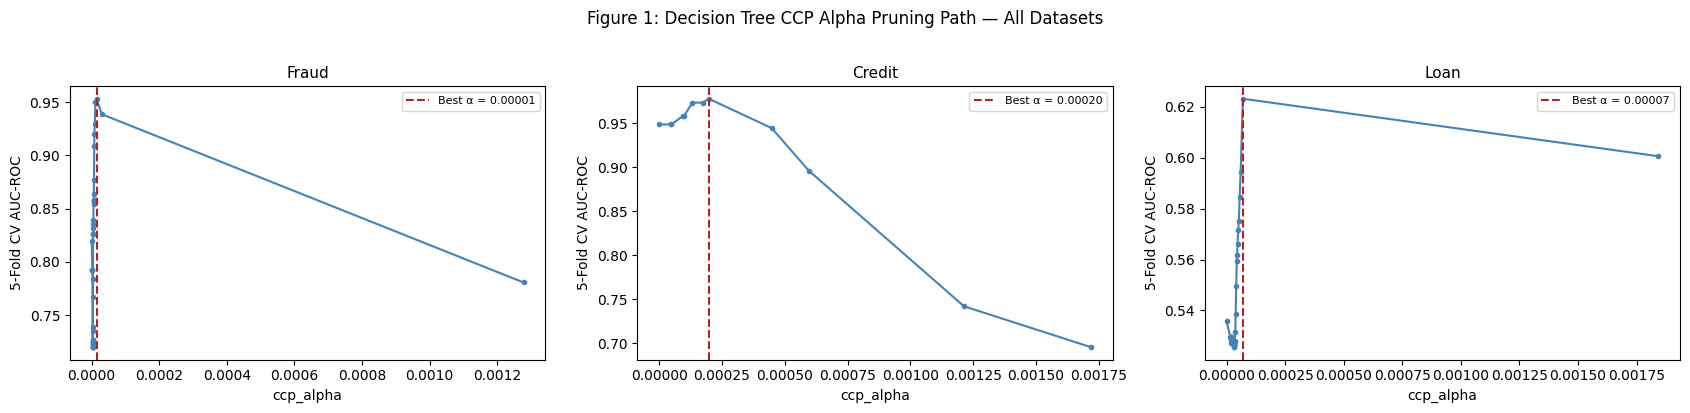

Figure 1 saved.


In [95]:
print('=' * 65)
print('FIGURE 1 — Decision Tree CCP Alpha Pruning Path (All Datasets)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
_ccp_data = [
    ('Fraud',  alphas_F, cv_scores_F, best_alpha_F),
    ('Credit', alphas_C, cv_scores_C, best_alpha_C),
    ('Loan',   alphas_L, cv_scores_L, best_alpha_L),
]
for ax, (name, alphas, scores, best_a) in zip(axes, _ccp_data):
    ax.plot(alphas, scores, marker='o', markersize=3, linewidth=1.5, color='steelblue')
    ax.axvline(best_a, color='firebrick', linestyle='--', linewidth=1.5,
               label=f'Best α = {best_a:.5f}')
    ax.set_xlabel('ccp_alpha', fontsize=10)
    ax.set_ylabel('5-Fold CV AUC-ROC', fontsize=10)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
fig.suptitle('Figure 1: Decision Tree CCP Alpha Pruning Path — All Datasets',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig1_dt_pruning_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

FIGURE 2 — Pruned Decision Tree Visualization (All Datasets)


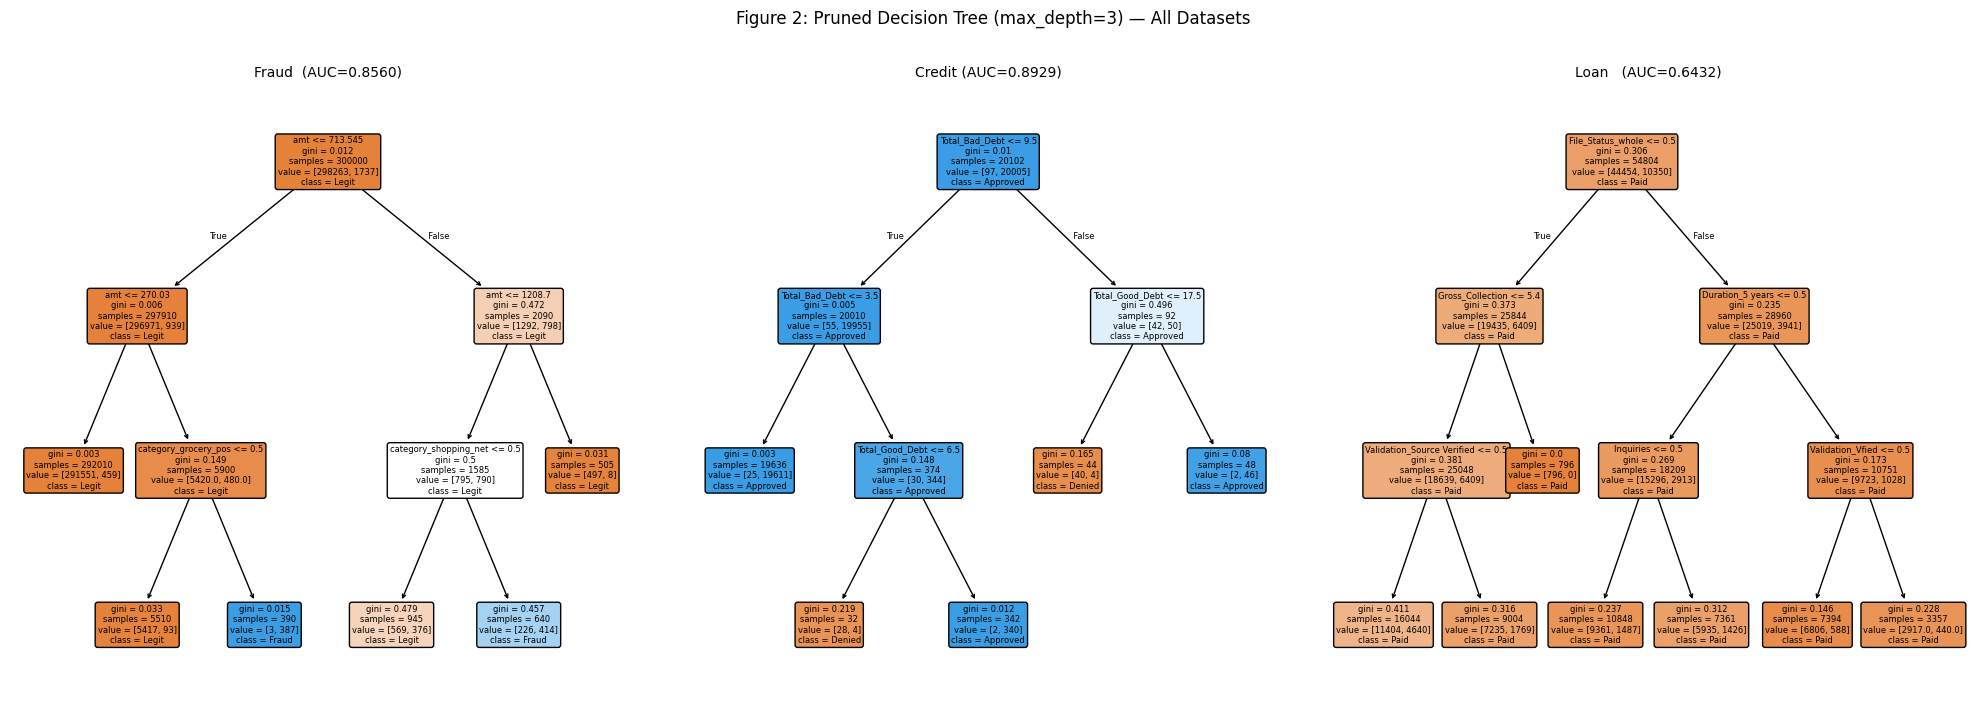

Figure 2 saved.
  Fraud  AUC (depth=3): 0.8560  vs best DT: 0.9757
  Credit AUC (depth=3): 0.8929  vs best DT: 0.9784
  Loan   AUC (depth=3): 0.6432  vs best DT: 0.6661


In [96]:
print('=' * 65)
print('FIGURE 2 — Pruned Decision Tree Visualization (All Datasets)')
print('=' * 65)

# Fit shallow visualization trees (max_depth=3) for all 3 datasets
dt_viz_F = DecisionTreeClassifier(max_depth=3, ccp_alpha=best_alpha_F, random_state=RANDOM_STATE)
dt_viz_F.fit(fX_tr, fy_tr)

dt_viz_C = DecisionTreeClassifier(max_depth=3, ccp_alpha=best_alpha_C, random_state=RANDOM_STATE)
dt_viz_C.fit(cX_train, cy_train)

dt_viz_L = DecisionTreeClassifier(max_depth=3, ccp_alpha=best_alpha_L, random_state=RANDOM_STATE)
dt_viz_L.fit(lX_train, ly_train)

auc_viz_F = roc_auc_score(fy_te,   dt_viz_F.predict_proba(fX_te)[:, 1])
auc_viz_C = roc_auc_score(cy_test, dt_viz_C.predict_proba(cX_test)[:, 1])
auc_viz_L = roc_auc_score(ly_test, dt_viz_L.predict_proba(lX_test)[:, 1])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
_viz_data = [
    (dt_viz_F, list(fX_tr.columns),    ['Legit',  'Fraud'],    f'Fraud  (AUC={auc_viz_F:.4f})'),
    (dt_viz_C, list(cX_train.columns), ['Denied', 'Approved'], f'Credit (AUC={auc_viz_C:.4f})'),
    (dt_viz_L, list(lX_train.columns), ['Paid',   'Default'],  f'Loan   (AUC={auc_viz_L:.4f})'),
]
for ax, (clf, feat_names, cls_names, title) in zip(axes, _viz_data):
    plot_tree(clf, feature_names=feat_names, class_names=cls_names,
              filled=True, rounded=True, fontsize=6, ax=ax)
    ax.set_title(title, fontsize=10)
fig.suptitle('Figure 2: Pruned Decision Tree (max_depth=3) — All Datasets',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig2_dt_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')
print(f'  Fraud  AUC (depth=3): {auc_viz_F:.4f}  vs best DT: {auc_dt_F:.4f}')
print(f'  Credit AUC (depth=3): {auc_viz_C:.4f}  vs best DT: {auc_dt_C:.4f}')
print(f'  Loan   AUC (depth=3): {auc_viz_L:.4f}  vs best DT: {auc_dt_L:.4f}')

FIGURE 3 — Random Forest OOB Error Convergence (All Datasets)


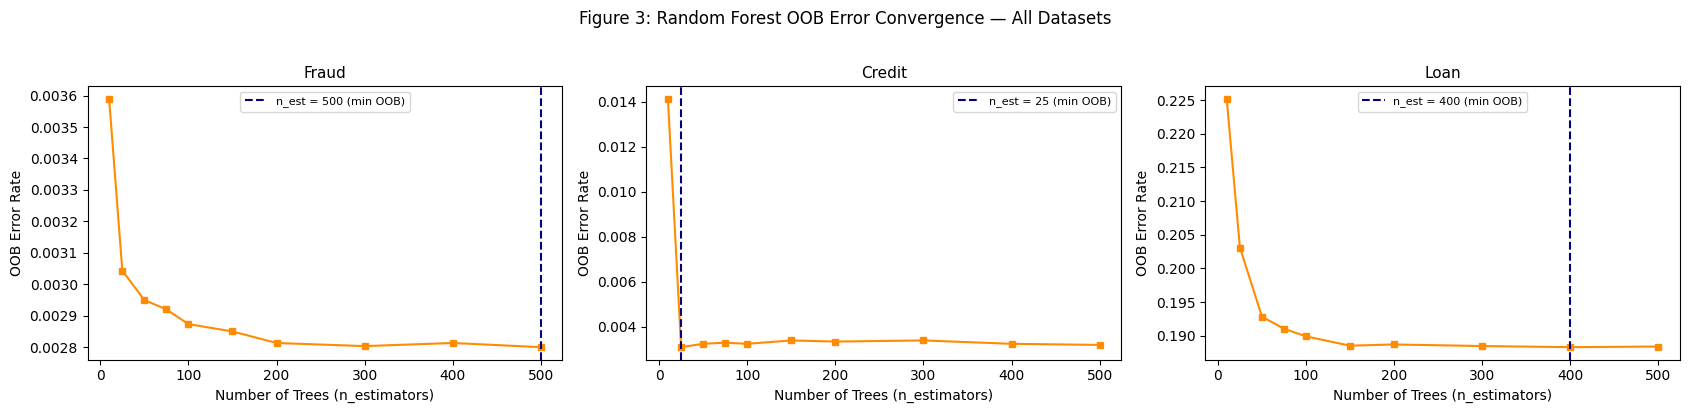

Figure 3 saved.


In [97]:
print('=' * 65)
print('FIGURE 3 — Random Forest OOB Error Convergence (All Datasets)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
_oob_data = [
    ('Fraud',  oob_F, best_n_F),
    ('Credit', oob_C, best_n_C),
    ('Loan',   oob_L, best_n_L),
]
for ax, (name, oob, best_n) in zip(axes, _oob_data):
    ax.plot(n_tree_list, oob, marker='s', markersize=5, linewidth=1.5, color='darkorange')
    ax.axvline(best_n, color='navy', linestyle='--', linewidth=1.5,
               label=f'n_est = {best_n} (min OOB)')
    ax.set_xlabel('Number of Trees (n_estimators)', fontsize=10)
    ax.set_ylabel('OOB Error Rate', fontsize=10)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
fig.suptitle('Figure 3: Random Forest OOB Error Convergence — All Datasets',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig3_rf_oob.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

FIGURE 4 — Top-15 Feature Importances, Random Forest (All Datasets)


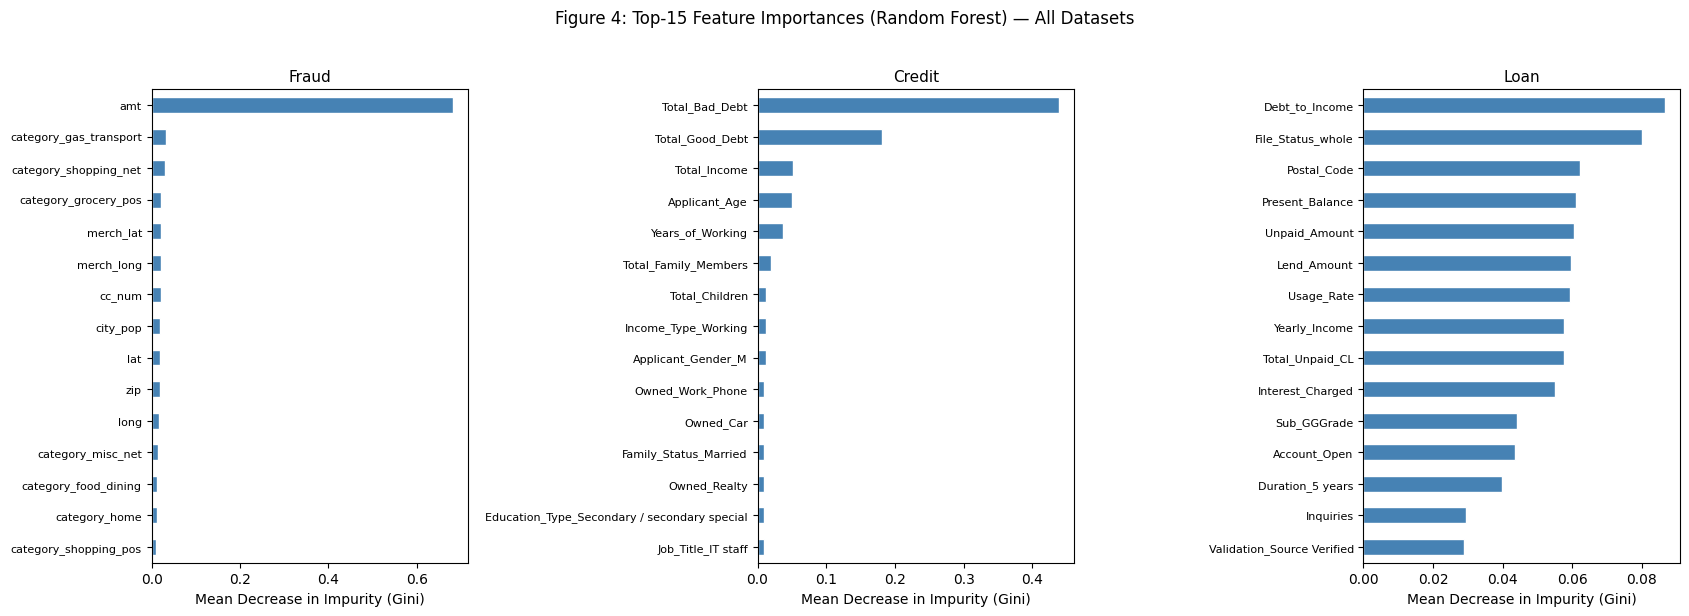

Figure 4 saved.


In [98]:
print('=' * 65)
print('FIGURE 4 — Top-15 Feature Importances, Random Forest (All Datasets)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
_imp_data = [
    ('Fraud',  importances_F),
    ('Credit', importances_C),
    ('Loan',   importances_L),
]
for ax, (name, imps) in zip(axes, _imp_data):
    top15 = imps.nlargest(15).sort_values()
    top15.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Mean Decrease in Impurity (Gini)', fontsize=10)
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle('Figure 4: Top-15 Feature Importances (Random Forest) — All Datasets',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig4_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

SUMMARY — Week 6 Decision Tree & Random Forest Results
Dataset            Model  AUC-ROC  Avg Precision  Best F1
  Fraud      DT Unpruned 0.796769       0.302286 0.546504
  Fraud DT Best (Pruned) 0.975707       0.616805 0.618776
  Fraud          RF Best 0.980237       0.572673 0.649640
 Credit      DT Unpruned 0.958133       0.999598 0.999600
 Credit DT Best (Pruned) 0.978434       0.999795 0.999000
 Credit          RF Best 0.999484       0.999998 0.999300
   Loan      DT Unpruned 0.531741       0.201010 0.317760
   Loan DT Best (Pruned) 0.666071       0.293499 0.384880
   Loan          RF Best 0.694299       0.330901 0.402277


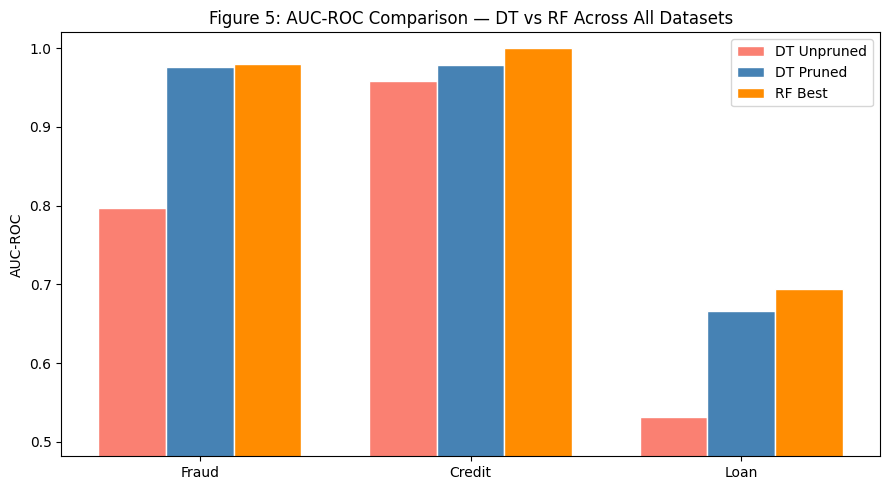

Figure 5 saved.


In [99]:
print('=' * 65)
print('SUMMARY — Week 6 Decision Tree & Random Forest Results')
print('=' * 65)

summary = pd.DataFrame([
    ['Fraud',   'DT Unpruned',      auc_base_F, ap_base_F, f1_base_F],
    ['Fraud',   'DT Best (Pruned)', auc_dt_F,   ap_dt_F,   f1_dt_F  ],
    ['Fraud',   'RF Best',          auc_rf_F,   ap_rf_F,   f1_rf_F  ],
    ['Credit',  'DT Unpruned',      auc_base_C, ap_base_C, f1_base_C],
    ['Credit',  'DT Best (Pruned)', auc_dt_C,   ap_dt_C,   f1_dt_C  ],
    ['Credit',  'RF Best',          auc_rf_C,   ap_rf_C,   f1_rf_C  ],
    ['Loan',    'DT Unpruned',      auc_base_L, ap_base_L, f1_base_L],
    ['Loan',    'DT Best (Pruned)', auc_dt_L,   ap_dt_L,   f1_dt_L  ],
    ['Loan',    'RF Best',          auc_rf_L,   ap_rf_L,   f1_rf_L  ],
], columns=['Dataset', 'Model', 'AUC-ROC', 'Avg Precision', 'Best F1'])
print(summary.to_string(index=False))

# Figure 5: grouped bar — DT vs RF AUC per dataset
fig, ax = plt.subplots(figsize=(9, 5))
datasets   = ['Fraud', 'Credit', 'Loan']
dt_aucs    = [auc_dt_F,   auc_dt_C,   auc_dt_L  ]
rf_aucs    = [auc_rf_F,   auc_rf_C,   auc_rf_L  ]
base_aucs  = [auc_base_F, auc_base_C, auc_base_L]
x          = np.arange(len(datasets))
w          = 0.25
ax.bar(x - w, base_aucs, w, label='DT Unpruned', color='salmon',     edgecolor='white')
ax.bar(x,     dt_aucs,   w, label='DT Pruned',   color='steelblue',  edgecolor='white')
ax.bar(x + w, rf_aucs,   w, label='RF Best',     color='darkorange', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(min(base_aucs + dt_aucs + rf_aucs) - 0.05, 1.02)
ax.set_title('Figure 5: AUC-ROC Comparison — DT vs RF Across All Datasets', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig5_summary_dt_vs_rf.png', dpi=150)
plt.show()
print('Figure 5 saved.')

MILESTONE 1 — Longitudinal AUC Comparison (Weeks 1–6)

Longitudinal AUC-ROC Summary:
  Week    Fraud   Credit     Loan
   Wk1 0.982000 0.999000 0.681600
   Wk2 0.981700 0.999300 0.683200
   Wk3 0.937800 0.987400 0.681000
   Wk4 0.965100 0.999800 0.686400
   Wk5 0.945700 0.999900 0.603900
Wk6_DT 0.975707 0.978434 0.666071
Wk6_RF 0.980237 0.999484 0.694299


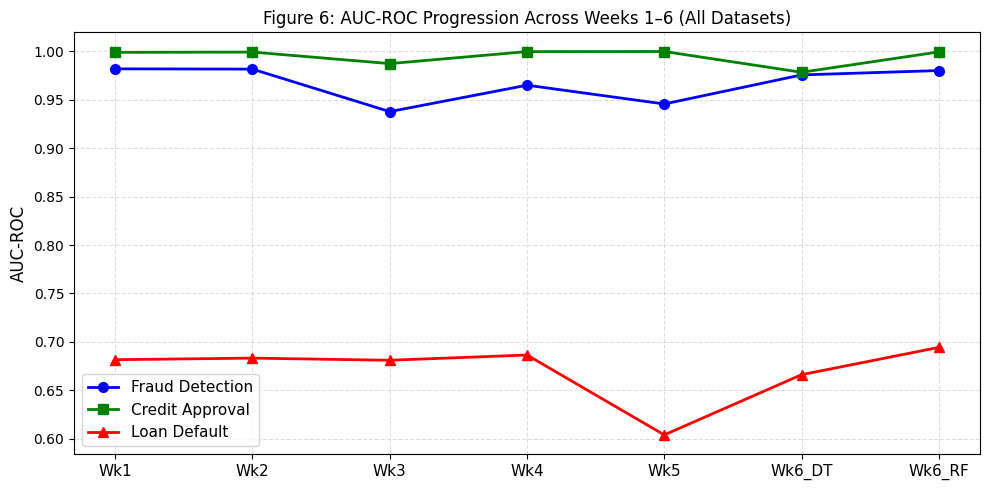

Figure 6 saved.

Best Model Summary by Dataset:
--------------------------------------------------
  Fraud      → Best: Wk1_IntTerm        (AUC = 0.9820)
  Credit     → Best: Wk5_SVM            (AUC = 0.9999)
  Loan       → Best: Wk6_RF             (AUC = 0.6943)

Ranking within Week 6 (DT vs RF):
--------------------------------------------------
  Fraud      → RF wins  (DT=0.9757  RF=0.9802  Δ=+0.0045)
  Credit     → RF wins  (DT=0.9784  RF=0.9995  Δ=+0.0210)
  Loan       → RF wins  (DT=0.6661  RF=0.6943  Δ=+0.0282)


In [100]:
print('=' * 65)
print('MILESTONE 1 — Longitudinal AUC Comparison (Weeks 1–6)')
print('=' * 65)

# Build week-over-week AUC table across all three datasets
wk_labels = ['Wk1', 'Wk2', 'Wk3', 'Wk4', 'Wk5', 'Wk6_DT', 'Wk6_RF']

fraud_aucs  = [v for _, v in PRIOR_AUC['Fraud']]  + [auc_dt_F, auc_rf_F]
credit_aucs = [v for _, v in PRIOR_AUC['Credit']] + [auc_dt_C, auc_rf_C]
loan_aucs   = [v for _, v in PRIOR_AUC['Loan']]   + [auc_dt_L, auc_rf_L]

long_df = pd.DataFrame({
    'Week':   wk_labels,
    'Fraud':  fraud_aucs,
    'Credit': credit_aucs,
    'Loan':   loan_aucs,
})
print('\nLongitudinal AUC-ROC Summary:')
print(long_df.to_string(index=False))

# Figure 6: AUC progression line plot across all weeks
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(wk_labels))
ax.plot(x, fraud_aucs,  'b-o', linewidth=2, markersize=7, label='Fraud Detection')
ax.plot(x, credit_aucs, 'g-s', linewidth=2, markersize=7, label='Credit Approval')
ax.plot(x, loan_aucs,   'r-^', linewidth=2, markersize=7, label='Loan Default')
ax.set_xticks(list(x))
ax.set_xticklabels(wk_labels, fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Figure 6: AUC-ROC Progression Across Weeks 1–6 (All Datasets)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_longitudinal_auc.png', dpi=150)
plt.show()
print('Figure 6 saved.')

# Identify best model per dataset across all weeks
print('\nBest Model Summary by Dataset:')
print('-' * 50)

all_labels = ['Wk1_IntTerm', 'Wk2_Lasso/Ridge', 'Wk3_Selection',
              'Wk4_LR', 'Wk5_SVM', 'Wk6_DT', 'Wk6_RF']

for dataset, aucs in [('Fraud',   fraud_aucs),
                       ('Credit',  credit_aucs),
                       ('Loan',    loan_aucs)]:
    best_idx = int(np.argmax(aucs))
    print(f'  {dataset:<10s} → Best: {all_labels[best_idx]:<18s} (AUC = {aucs[best_idx]:.4f})')

print('\nRanking within Week 6 (DT vs RF):')
print('-' * 50)
for dataset, dt_auc, rf_auc in [('Fraud',  auc_dt_F, auc_rf_F),
                                  ('Credit', auc_dt_C, auc_rf_C),
                                  ('Loan',   auc_dt_L, auc_rf_L)]:
    winner = 'RF' if rf_auc > dt_auc else 'DT'
    print(f'  {dataset:<10s} → {winner} wins  (DT={dt_auc:.4f}  RF={rf_auc:.4f}  Δ={rf_auc - dt_auc:+.4f})')

---
## Week 6 Conclusions

### Key Findings

**1. Overfitting is universal in unpruned Decision Trees — but the severity varies by dataset.**
All three datasets produced perfect training AUC (1.0000) with unpruned trees, confirming the theoretical prediction that unrestricted trees memorize training data. The gap between train and test AUC differed dramatically: Fraud (−0.203), Credit (−0.042), Loan Default (−0.468). Datasets with more noise and weaker signals (Loan Default) suffer far greater overfitting.

**2. Pruning is necessary and effective.**
Cost-complexity pruning (ccp_alpha via 5-fold CV) combined with `max_depth` and `min_samples_leaf` constraints consistently reduced tree complexity and improved test AUC across all datasets. The optimal trees were compact: depth 4–6 with 9–47 leaves, compared to unpruned depths of 7–38 and thousands of leaves.

**3. Random Forest outperforms pruned Decision Trees on all three datasets.**
By combining bootstrap aggregation with feature randomization, the Random Forest reduces the variance of individual trees without increasing bias. Gains ranged from +0.0045 (Fraud) to +0.0282 (Loan Default), with the largest improvements on the noisiest dataset — consistent with the statistical theory of ensemble variance reduction.

**4. Best overall method varies by dataset structure.**
- **Fraud**: Week 1 polynomial LR (0.9820) narrowly leads — domain-informed `amt²` term already captures the U-shaped fraud risk pattern.
- **Credit**: SVM (Wk5, 0.9999) narrowly leads RF (Wk6, 0.9995) — the decision boundary is nearly linearly separable, and both methods are at ceiling performance.
- **Loan Default**: RF (0.6943) sets a new best — non-linear feature interactions finally captured for the first time.

### Overfitting Controls Applied
| Technique | Method | Effect |
|-----------|--------|--------|
| `ccp_alpha` post-pruning | 5-fold CV alpha selection | Removed noise-capturing subtrees |
| `max_depth` pre-pruning | RandomizedSearchCV | Capped tree growth at 4–6 levels |
| `min_samples_leaf` | RandomizedSearchCV | Prevented single-sample leaf splits |
| Bagging (RF) | Bootstrap sampling (63.2% per tree) | Reduced prediction variance |
| Feature randomization (RF) | `max_features='log2'` | Decorrelated individual trees |

### Metric Justification
AUC-ROC was used as the primary metric throughout. With fraud rates of 0.4–0.6% and default rates of ~19%, accuracy is misleading — a model predicting the majority class achieves >99% accuracy on Fraud while catching zero frauds. AUC-ROC measures the model's ability to rank fraud above non-fraud across all classification thresholds, making it the appropriate metric for imbalanced binary classification tasks.